In [1]:
import os
import sys
from glob import glob
import warnings

sys.path.insert(1, os.path.abspath(".."))
from pairs_python.core import pairs_quadtree as pqt

from datetime import datetime, timedelta
import pytz
import numpy
import pandas
os.environ['USE_PYGEOS'] = '0'
import geopandas
import pyarrow
import dask_geopandas
import shapely
from shapely import wkb, wkt
import pyproj
#import sqlite3
#import pysqlite3 as sqlite3

import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import vectorstore
"""
from importlib import reload 
reload(vectorstore)
"""

import math
import requests
import xarray as xr
import dask
import dask.dataframe

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

# Reading the entire vectorstore into dask-geopandas and plotting automatically-generated spatial partitions

In [2]:
# Note, all the parquet files in this folder need to belong to the vectorstore (REMOVE OVERVIEW PARQUETS)
filepath = '/data/vector/vectorstore/carbon_storage/'  

In [3]:
%%time
ddf = dask_geopandas.read_parquet(filepath, gather_spatial_partitions=True)
print('Number of partitions', ddf.npartitions)

Number of partitions 178
CPU times: user 155 ms, sys: 10 ms, total: 165 ms
Wall time: 165 ms


CPU times: user 104 ms, sys: 67.5 ms, total: 172 ms
Wall time: 99.7 ms


<AxesSubplot: >

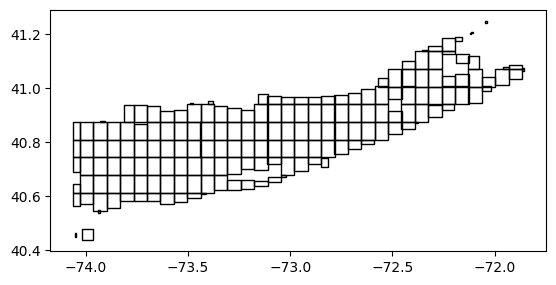

In [4]:
%%time
ddf.spatial_partitions.plot(color='none')

In [5]:
ddf.spatial_partitions

0      POLYGON ((-74.04658 40.45084, -74.04658 40.463...
1      POLYGON ((-73.96503 40.43749, -73.96503 40.479...
2      POLYGON ((-73.95399 40.43755, -73.95399 40.437...
3      POLYGON ((-73.93208 40.54020, -73.93208 40.547...
4      POLYGON ((-74.02818 40.56548, -74.02818 40.613...
                             ...                        
173    POLYGON ((-72.10645 41.20309, -72.10645 41.206...
174    POLYGON ((-72.03687 41.24334, -72.03687 41.250...
175    POLYGON ((-71.93092 41.07187, -71.93092 41.077...
176    POLYGON ((-71.86535 41.07162, -71.86535 41.085...
177    POLYGON ((-71.85734 41.07184, -71.85734 41.074...
Length: 178, dtype: geometry

## Try row group filters

In [6]:
# Load one partition
ddf10 = ddf.partitions[10].compute()
ddf10.tail(1)

,geom_id,timestamp,geomhash,carbon,diameter,borocode,fid,geometry,spatial_key,overview_level,intersection_flag,overview_key,partition_level9,partition_level11,filter_key_level15,filter_key_level17,filter_key_level19,filter_key_level21
114194,37741716,2021-08-18 20:20:44+00:00,9d64e255d08446dff40168ad8d891e77,0.010125,2.32379,99,17459,"POLYGON ((-73.90632 40.61336, -73.90629 40.613...",4108678,13,False,level13_4108678,16049,256792,65738853.0,1.051822e+09,1.682915e+10,2.692663e+11


<AxesSubplot: >

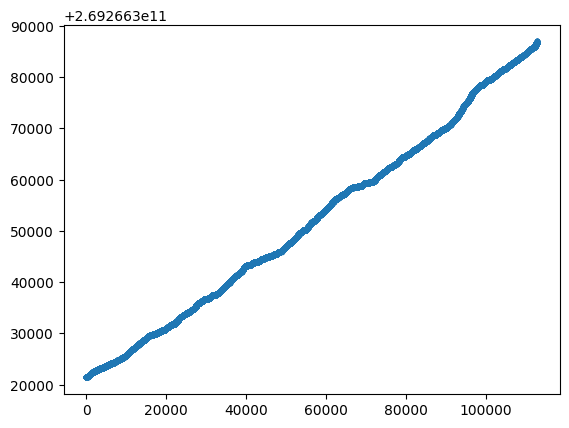

In [7]:
# Sort by filter-key levels
df = ddf10.sort_values(by=['filter_key_level15', 'filter_key_level17', 'filter_key_level19', 'filter_key_level21']).reset_index(drop=True)
df['filter_key_level21'].plot(lw=0, marker='.')

In [8]:
%%time
# Write to a parquet with row groups of equal size
filepath = '/data/vector/tmp/tmp.parquet'
df.to_parquet(filepath, engine='pyarrow', compression='snappy', row_group_size=4000)

CPU times: user 937 ms, sys: 223 ms, total: 1.16 s
Wall time: 1.17 s


In [9]:
%%time
# Read it back, splitting the row groups into individual partitions
ddf2 = dask_geopandas.read_parquet(filepath, split_row_groups=1)
ddf2.spatial_partitions#.plot(color='none')

CPU times: user 100 ms, sys: 6.28 ms, total: 106 ms
Wall time: 98.6 ms


0     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
1     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
2     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
3     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
4     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
5     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
6     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
7     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
8     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
9     POLYGON ((-73.89702 40.61307, -73.89702 40.678...
10    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
11    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
12    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
13    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
14    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
15    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
16    POLYGON ((-73.89702 40.61307, -73.89702 40.678...
17    POLYGON ((-73.89702 40.61307, -73.89702 40

In [10]:
%%time
# Compute the total bounds of each row-group
[p.total_bounds.compute() for p in ddf2.partitions]

CPU times: user 2.62 s, sys: 183 ms, total: 2.81 s
Wall time: 2.71 s


[array([-73.962742  ,  40.61324896, -73.94637289,  40.6214398 ]),
 array([-73.96274672,  40.61741815, -73.94637289,  40.629628  ]),
 array([-73.96274739,  40.61324983, -73.93001836,  40.62962391]),
 array([-73.96271977,  40.6138095 , -73.92999188,  40.63065472]),
 array([-73.96274672,  40.62963209, -73.94842039,  40.63782092]),
 array([-73.96274672,  40.62963209, -73.94637762,  40.64600874]),
 array([-73.96245027,  40.62963618, -73.92999188,  40.64601283]),
 array([-73.94636684,  40.63782501, -73.92999188,  40.64601366]),
 array([-73.94598415,  40.61324983, -73.91360075,  40.64601366]),
 array([-73.92997571,  40.61324983, -73.89927442,  40.62962883]),
 array([-73.91359536,  40.61324983, -73.89722087,  40.62702308]),
 array([-73.91359044,  40.62144476, -73.89722087,  40.62962883]),
 array([-73.9299811 ,  40.61520558, -73.89722134,  40.6419117 ]),
 array([-73.9299811 ,  40.62963292, -73.90131766,  40.64601366]),
 array([-73.91359044,  40.62965337, -73.89722673,  40.64601366]),
 array([-7

In [11]:
%%time
# Compute the total bounds of each row-group
lst_bbox = ddf2['geometry'].map_partitions(lambda x: shapely.box(*x.total_bounds)).compute()
lst_bbox

CPU times: user 2.76 s, sys: 493 ms, total: 3.26 s
Wall time: 2.45 s


0     POLYGON ((-73.9463728947473 40.6132489607595, ...
1     POLYGON ((-73.9463728947473 40.6174181495976, ...
2     POLYGON ((-73.930018362076 40.6132498326563, -...
3     POLYGON ((-73.9299918821296 40.6138095047203, ...
4     POLYGON ((-73.948420385306 40.6296320866948, -...
5     POLYGON ((-73.9463776163499 40.6296320866948, ...
6     POLYGON ((-73.9299918821296 40.6296361772702, ...
7     POLYGON ((-73.9299918821296 40.6378250068052, ...
8     POLYGON ((-73.9136007519435 40.6132498326563, ...
9     POLYGON ((-73.8992744197923 40.6132498326563, ...
10    POLYGON ((-73.8972208710528 40.6132498326563, ...
11    POLYGON ((-73.8972208710528 40.621444762514, -...
12    POLYGON ((-73.8972213405649 40.6152055787313, ...
13    POLYGON ((-73.9013176582605 40.629632917558, -...
14    POLYGON ((-73.8972267304566 40.6296533704323, ...
15    POLYGON ((-73.8972698495902 40.6296574610064, ...
16    POLYGON ((-73.938179591067 40.6460169215707, -...
17    POLYGON ((-73.9300457810466 40.64601692157

<AxesSubplot: >

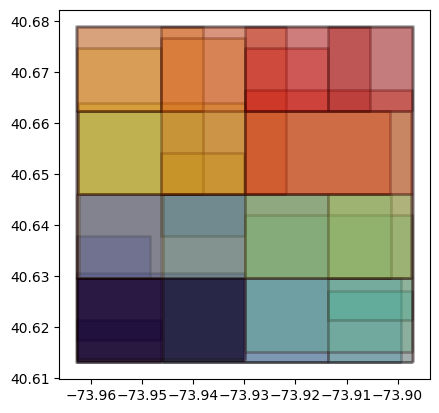

In [12]:
# Simulate what the partition bounds would look like inside on PAIRS overview cell
gdf_bbox = geopandas.GeoDataFrame(crs='epsg:4326', geometry=lst_bbox)
ax = gdf_bbox.plot(lw=2, edgecolor='k', cmap='jet', alpha=0.3, aspect='equal')
i = 2
gdf_bbox.loc[[i], :].plot(color='k', alpha=0.58, ax=ax, aspect='equal')

In [13]:
%%time
# Read the file with geopandas (not dask-geopandas)
gdf2 = geopandas.read_parquet(filepath)
gdf2.tail(1)

CPU times: user 859 ms, sys: 374 ms, total: 1.23 s
Wall time: 622 ms


,geom_id,timestamp,geomhash,carbon,diameter,borocode,fid,geometry,spatial_key,overview_level,intersection_flag,overview_key,partition_level9,partition_level11,filter_key_level15,filter_key_level17,filter_key_level19,filter_key_level21
114194,37741685,2021-08-18 20:20:44+00:00,b91bbd92e6b21a1c950c845241db86d0,0.0081,2.07846,99,13089,"POLYGON ((-73.92999 40.61699, -73.92998 40.616...",4108678,13,False,level13_4108678,16049,256792,NaN,NaN,NaN,NaN


In [14]:
metadata = pyarrow.parquet.read_metadata(filepath)
metadata

  created_by: parquet-cpp-arrow version 10.0.0
  num_columns: 18
  num_rows: 114195
  num_row_groups: 29
  format_version: 2.6
  serialized_size: 128853

In [15]:
pyarrow.parquet.RowGroupMetaData

pyarrow._parquet.RowGroupMetaData

In [16]:
metadata.row_group(10)

  num_columns: 18
  num_rows: 4000
  total_byte_size: 2814651

In [17]:
print(len(gdf2.columns))
metadata
numpy.argmax(gdf2.columns=='geometry')

18


7

In [18]:
# It looks like the geometry column was treated as a numeric column?????
metadata.row_group(9).column(7)

  file_offset: 9547825
  file_path: 
  physical_type: BYTE_ARRAY
  num_values: 4000
  path_in_schema: geometry
  is_stats_set: True
  statistics:
      has_min_max: True
      min: b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\x01\x01\xa1/hzR\xc0\xc9|\x16\x14\xc3ND@\xdb\xa6\x05\x19hzR\xc0\xc9|\x16\x14\xc3ND@\xdb\xa6\x05\x19hzR\xc0E\x82\x1f\xad\xc2ND@\x01\x01\xa1/hzR\xc0E\x82\x1f\xad\xc2ND@\x01\x01\xa1/hzR\xc0\xc9|\x16\x14\xc3ND@'
      max: b'\x01\x03\x00\x00\x00\x03\x00\x00\x00:\x00\x00\x00\xa5kPY{zR\xc0\xcf\xcb1\xed\xe6OD@\xe6\xa8G\xe8zzR\xc0\xcf\xcb1\xed\xe6OD@\xe6\xa8G\xe8zzR\xc0W\xa4\xe0\xca\xe6OD@\x0c\x03\xe3\xfezzR\xc0W\xa4\xe0\xca\xe6OD@\x0c\x03\xe3\xfezzR\xc0\xf7T>\x86\xe6OD@\xc0N\xac\xd1zzR\xc0\xf7T>\x86\xe6OD@\xc0N\xac\xd1zzR\xc0\x83\xb4\xf9\xfc\xe5OD@\x99\xf4\x10\xbbzzR\xc0\x83\xb4\xf9\xfc\xe5OD@\x99\xf4\x10\xbbzzR\xc0\x0e\x8c\xa8\xda\xe5OD@M@\xda\x8dzzR\xc0\x0e\x8c\xa8\xda\xe5OD@M@\xda\x8dzzR\xc0ocW\xb8\xe5OD@s\x9au\xa4zzR\xc0ocW\xb8\xe5OD@s\x9au\xa4zzR\xc0\xda\xe

In [19]:
%%time
# Another way to look at metadata usin pyarrow
json.loads(pyarrow.parquet.ParquetDataset(filepath, use_legacy_dataset=False).schema.metadata[b"geo"])["columns"]["geometry"]["bbox"]

CPU times: user 4.48 ms, sys: 150 µs, total: 4.63 ms
Wall time: 4.31 ms


[-73.9629784828004, 40.6130698029436, -73.8970160551681, 40.6789143335766]